In [21]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import sdevelo
import warnings
import torch

In [22]:
# Check if GPU is available
print(torch.cuda.is_available())

True


In [23]:
# Suppress specific MatplotlibDeprecationWarning from the scvelo plotting module
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning) # , module="scvelo.plotting.utils"

In [24]:
# Read input file
adata = scanpy.read_h5ad("RNA Sequencing Data/splice_counts_mm10.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day'
    var: 'ensemble_ids', 'gene_symbol'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


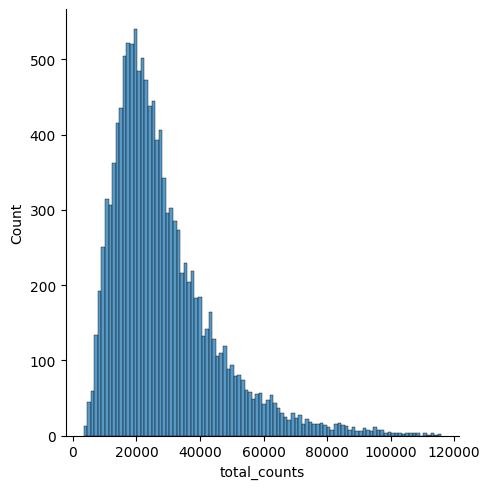

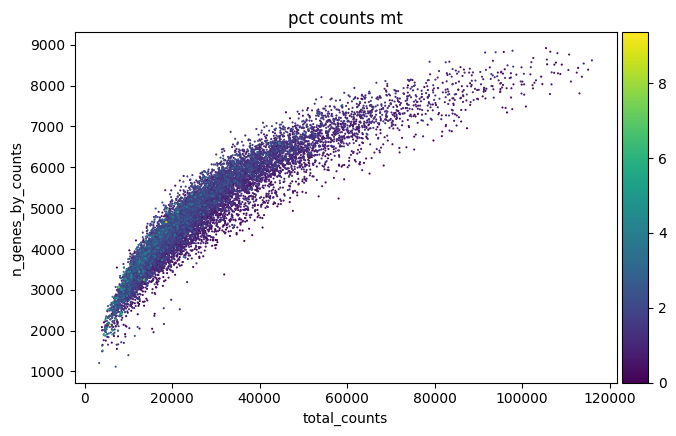

In [25]:
# Quality control

adata.var["mt"] = adata.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata, inplace=True, percent_top=[], log1p=False
)
histogram = seaborn.displot(adata.obs["total_counts"], bins=100, kde=False)
scatter = scanpy.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

View of AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


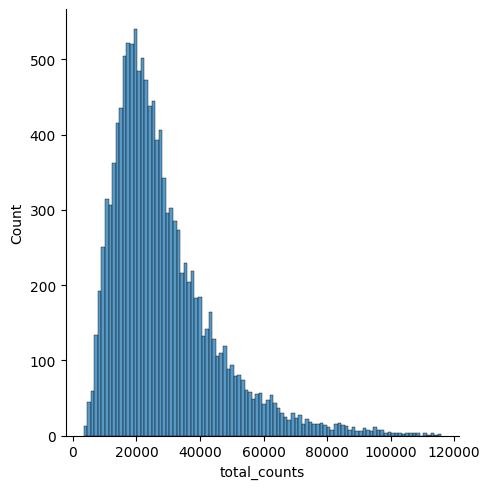

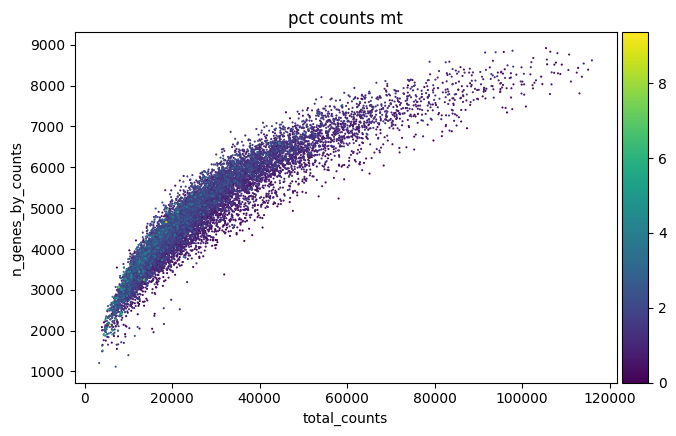

In [26]:
# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata.obs["n_genes_by_counts"] >= 200)*(adata.obs['total_counts'] <= 150000)*(adata.obs['pct_counts_mt'] < 10)
adata = adata[included_cells]
print(adata)
histogram = seaborn.displot(adata.obs["total_counts"], bins=100, kde=False)
scatter = scanpy.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

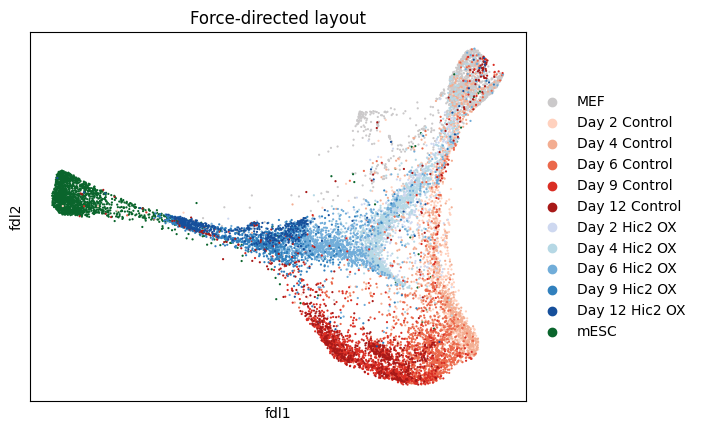

In [27]:
# Plot FDL

scanpy.pl.embedding(basis='fdl', adata=adata, color="sample", size=10, title="Force-directed layout")

In [28]:
# # Filter, normalize and find neighbors moments
# scvelo.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
# scvelo.pp.moments(adata, n_neighbors=30, n_pcs=30)

In [29]:
# Define SDEvelo arguments
args = sdevelo.Config()
args.vis_key = "X_fdl"
args.vis_type_col = "sample"
args.scv_n_jobs = 20
args.n_gene = 2000
args.seed = 0
args.cuda_device = 0

In [30]:
# Train SDEvelo model
model = sdevelo.SDENN(args, adata)
adata = model.train(600)

cuda
Filtered out 35658 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
Using scVelo version 0.3.3


/home/love/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
5000
Epoch: 0, Loss: 0.834, alpha: 12.84, beta: 11.23, gamma: 1.13, s1: 0.010, s2: 0.010,  t_m: 0.674,  u_shift: 0.000,  s_shift: -0.012
Epoch: 50, Loss: 0.642, alpha: 3.33, beta: 6.84, gamma: 0.01, s1: 0.010, s2: 0.015,  t_m: 0.856,  u_shift: 0.000,  s_shift: -0.087
Epoch: 100, Loss: 0.534, alpha: 12.94, beta: 20.55, gamma: 6.04, s1: 0.012, s2: 0.010,  t_m: 0.695,  u_shift: 0.000,  s_shift: -0.009
Epoch: 150, Loss: 0.473, alpha: 20.43, beta: 36.09, gamma: 10.53, s1: 0.011, s2: 0.011,  t_m: 0.783,  u_shift: 0.000,  s_shift: 0.033
Epoch: 200, Loss: 0.440, alpha: 29.83, beta: 53.13, gamma: 15.24, s1: 0.010, s2: 0.021,  t_m: 0.812,  u_shift: 0.000,  s_shift: 0.100
Epoch: 250, Loss: 0.414, alpha: 30.90, beta: 55.25, gamma: 15.79, s1: 0.020, s2: 0.010,  t_m: 0.816,  u_shift: 0.000,  s_shift: 0.100
Epoch: 300, Loss: 0.414, alpha: 32.37, beta: 58.02, g

In [52]:
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'sample_colors', 'log1p', 'pca', 'neighbors'
    obsm: 'X_fdl', 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'sde_velocity', 'pred_u', 'pred_s'
    obsp: 'distances', 'connectivities'


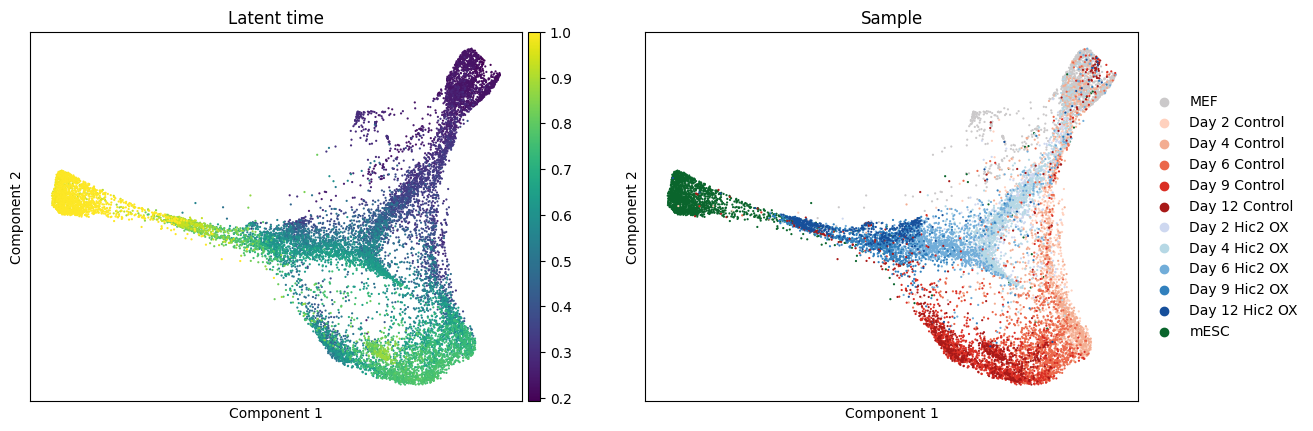

In [31]:
# Plot latent time
axis_list = scanpy.pl.embedding(basis='fdl', adata=adata, color=["latent_time", "sample"], size=10, title=["Latent time", "Sample"], show=False)
for axis in axis_list:
    axis.set_xlabel("Component 1")
    axis.set_ylabel("Component 2")
pyplot.show()

In [32]:
# Velocity cosine correlations
scvelo.tl.velocity_graph(adata, vkey="sde_velocity", n_jobs=16)

computing velocity graph (using 16/16 cores)


  0%|          | 0/12791 [00:00<?, ?cells/s]

/home/love/miniconda3/envs/velocity/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=14738) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:35) --> added 
    'sde_velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:01) --> added
    'sde_velocity_fdl', embedded velocity vectors (adata.obsm)


/home/love/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/love/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/love/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/love/miniconda3/envs/velocity/lib/python3.12/site

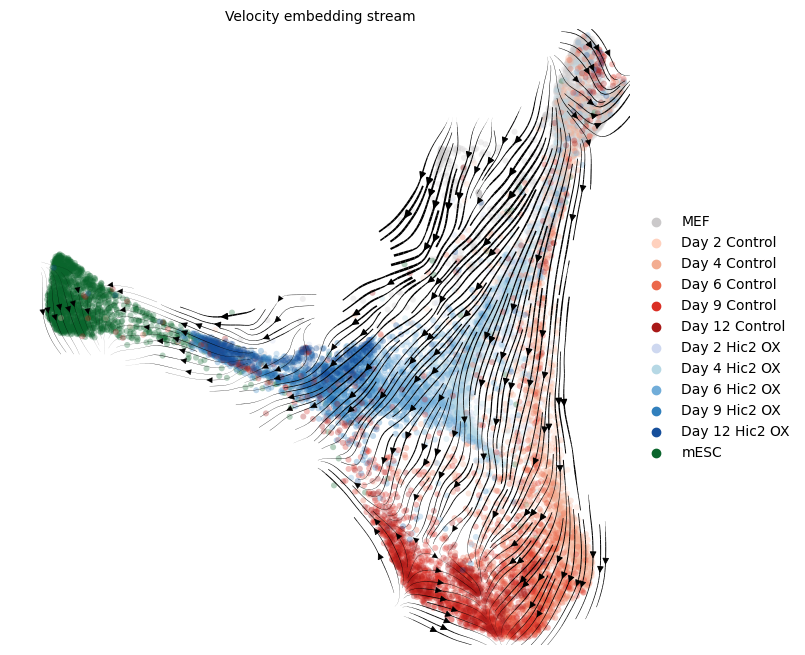

In [33]:
scvelo.pl.velocity_embedding_stream(adata, vkey="sde_velocity", basis="fdl", color="sample", legend_loc="right", figsize=(8,8), title="Velocity embedding stream", density=4)

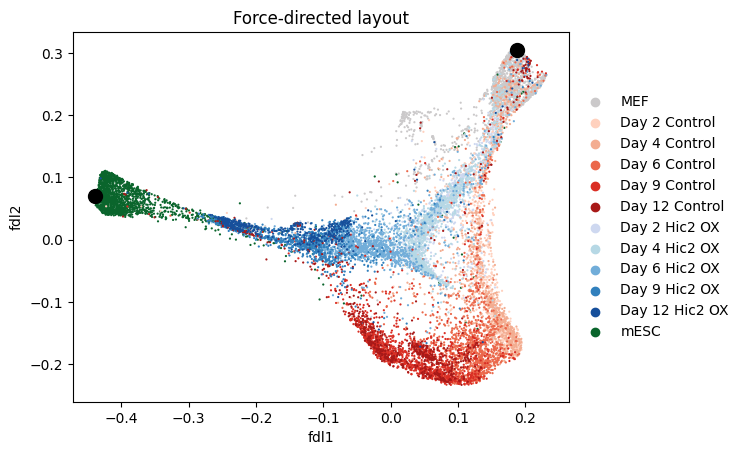

In [34]:
# Find good root and end cells

# Find root
root_filter = (adata.obs["group"]=="MEF")
# Use MEF cell with largest UMAP2, ignoring outliers with >10
root_index = numpy.argmax(adata[root_filter].obsm["X_fdl"][:,1])
root_barcode = adata[root_filter].obs.index[root_index]
adata.obs["manual_root"] = False
adata.obs["manual_root"].loc[root_barcode] = True

# Find end
end_filter = adata.obs["group"]=="mESC"
# Use mESC cell with smallest UMAP1
end_index = numpy.argmin(adata[end_filter].obsm["X_fdl"][:,0])
end_barcode = adata[end_filter].obs.index[end_index]
adata.obs["manual_end"] = False
adata.obs["manual_end"].loc[end_barcode] = True

ax = scanpy.pl.embedding(basis='fdl', adata=adata, color="sample", size=10, title="Force-directed layout", show=False)

# Plot UMAP
ax.scatter(*adata[adata.obs["manual_end"]].obsm["X_fdl"][0], marker="o", s=100, color="black")
ax.scatter(*adata[adata.obs["manual_root"]].obsm["X_fdl"][0], marker="o", s=100, color="black")
ax.yaxis.set_major_locator(matplotlib.ticker.AutoLocator())
ax.xaxis.set_major_locator(matplotlib.ticker.AutoLocator())

pyplot.show()

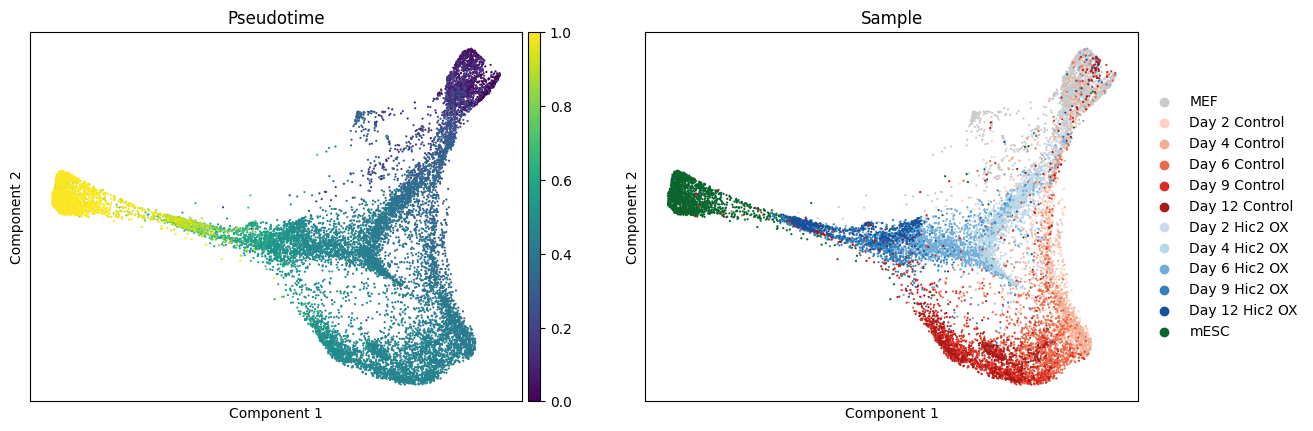

In [38]:
# Pseudotime
global_root_index = numpy.argmax(adata.obs.index == root_barcode)
global_end_index = numpy.argmax(adata.obs.index == end_barcode)

scvelo.tl.velocity_pseudotime(adata, root_key=global_root_index, end_key=global_end_index, vkey="sde_velocity")

# Plot velocities colored by latent time
axis_list = scanpy.pl.embedding(basis='fdl', adata=adata, color=["sde_velocity_pseudotime", "sample"], size=10, title=["Pseudotime", "Sample"], show=False)
for axis in axis_list:
    axis.set_xlabel("Component 1")
    axis.set_ylabel("Component 2")
pyplot.show()

In [61]:
# Save adata object
adata.write_h5ad(
    "/scratch/lema/m26_losu/velocity_sdevelo.h5ad",
    compression=hdf5plugin.FILTERS["zstd"]
)